# Network Graph Analysis: Relationship Intelligence from Enriched LinkedIn Data

**Ascendancy Technical Exercise** | Tomi Brasca

This notebook analyzes a dataset of 248 enriched LinkedIn profiles to answer two questions:
1. **How well-connected is this network?**
2. **What groups, clusters, or communities does it consist of?**

The data contains no explicit edges — all relationships are inferred from shared attributes (companies, schools, locations). The core challenge is designing a meaningful edge-weighting scheme that reveals real structure beneath surface-level connections.

In [1]:
import json
import re
from datetime import datetime
from collections import defaultdict
from itertools import combinations

import polars as pl
import networkx as nx
import community as community_louvain
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

---
## 1. Data Loading & Cleaning

The raw data is an array of 248 enriched LinkedIn profiles. Key cleaning tasks:
- **Company normalization**: Clemson University has 7+ sub-entities that inflate edge counts
- **Deduplication**: Some people hold 9-14 roles at Clemson sub-departments
- **Date parsing**: Mixed `YYYY` and `YYYY-MM-DD` formats
- **Name cleanup**: Strip emoji characters

In [2]:
with open("data.json") as f:
    raw = json.load(f)

records = raw["data"]
print(f"Loaded {len(records)} records")
print(f"Available fields: {sorted(set().union(*(r.keys() for r in records)))}")

Loaded 248 records
Available fields: ['about', 'certifications', 'created_at', 'current_company_id', 'current_company_industry', 'current_company_linkedin_url', 'current_company_location', 'current_company_name', 'current_company_size', 'current_company_website', 'current_function', 'current_job_updated_at', 'current_location', 'current_seniority', 'current_title', 'education', 'experience', 'first_name', 'full_name', 'headline', 'id', 'interests', 'last_name', 'last_refresh_at', 'latest_company_change_at', 'latest_role_change_at', 'linkedin_url', 'other_locations', 'personal_emails', 'skills', 'smart_tags', 'social_media', 'updated_at', 'work_email']


In [3]:
CLEMSON_PATTERN = re.compile(r"clemson", re.IGNORECASE)
EMOJI_PATTERN = re.compile(
    r"[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF\U0001F680-\U0001F6FF"
    r"\U0001F1E0-\U0001F1FF\U00002702-\U000027B0\U0001FA00-\U0001FA6F"
    r"\U0001FA70-\U0001FAFF\U00002600-\U000026FF\U0000FE0F]+",
    flags=re.UNICODE,
)


def clean_name(name: str) -> str:
    return EMOJI_PATTERN.sub("", name).strip()


def is_clemson(name: str) -> bool:
    return bool(CLEMSON_PATTERN.search(name))


def normalize_company(name: str) -> str:
    if is_clemson(name):
        return "Clemson University"
    return name.strip()


def parse_date(d: str | None) -> datetime | None:
    if not d:
        return None
    try:
        return datetime.strptime(d[:10], "%Y-%m-%d")
    except ValueError:
        try:
            return datetime.strptime(d[:4], "%Y")
        except ValueError:
            return None


def has_temporal_overlap(exp1: dict, exp2: dict) -> bool:
    s1 = parse_date(exp1.get("start_date"))
    e1 = parse_date(exp1.get("end_date")) or datetime.now()
    s2 = parse_date(exp2.get("start_date"))
    e2 = parse_date(exp2.get("end_date")) or datetime.now()
    if not s1 or not s2:
        return False
    return s1 <= e2 and s2 <= e1


def get_linkedin_connections(record: dict) -> int | None:
    for sm in record.get("social_media", []):
        if sm.get("network") == "linkedin" and sm.get("connections"):
            return sm["connections"]
    return None


def get_clemson_grad_year(record: dict) -> int | None:
    for edu in record.get("education", []):
        school = edu.get("school", {}).get("name", "")
        if is_clemson(school) and edu.get("end_date"):
            year_str = edu["end_date"][:4]
            try:
                return int(year_str)
            except ValueError:
                pass
    return None


print("Utility functions defined.")

Utility functions defined.


In [4]:
nodes = []
for r in records:
    pid = r.get("id", r.get("linkedin_url"))
    clemson_aff = any(
        is_clemson(exp.get("company", {}).get("name", ""))
        for exp in r.get("experience", [])
    ) or any(
        is_clemson(edu.get("school", {}).get("name", ""))
        for edu in r.get("education", [])
    )

    nodes.append({
        "id": pid,
        "full_name": clean_name(r.get("full_name", "Unknown")),
        "linkedin_url": r.get("linkedin_url", ""),
        "current_title": r.get("current_title", ""),
        "current_company": r.get("current_company_name", ""),
        "current_industry": r.get("current_company_industry", ""),
        "current_location": r.get("current_location", ""),
        "clemson_affiliated": clemson_aff,
        "clemson_grad_year": get_clemson_grad_year(r),
        "linkedin_connections": get_linkedin_connections(r),
        "company_count": len(set(
            normalize_company(exp.get("company", {}).get("name", ""))
            for exp in r.get("experience", [])
            if exp.get("company", {}).get("name")
        )),
        "skills_list": r.get("skills", []),
        "experience": r.get("experience", []),
        "education": r.get("education", []),
    })

nodes_df = pl.DataFrame([
    {k: v for k, v in n.items() if k not in ("experience", "education")}
    for n in nodes
])

print(f"Nodes: {len(nodes_df)}")
print(f"Clemson-affiliated: {nodes_df.filter(pl.col('clemson_affiliated')).height}")
print(f"Non-Clemson: {nodes_df.filter(~pl.col('clemson_affiliated')).height}")
print(f"\nField completeness:")
for col in nodes_df.columns:
    dtype = nodes_df[col].dtype
    if dtype == pl.Utf8:
        non_null = nodes_df.filter(pl.col(col).is_not_null() & (pl.col(col) != "")).height
    else:
        non_null = nodes_df.filter(pl.col(col).is_not_null()).height
    print(f"  {col}: {non_null}/{len(nodes_df)} ({100*non_null/len(nodes_df):.0f}%)")

Nodes: 248
Clemson-affiliated: 136
Non-Clemson: 112

Field completeness:
  id: 248/248 (100%)
  full_name: 248/248 (100%)
  linkedin_url: 248/248 (100%)
  current_title: 246/248 (99%)
  current_company: 246/248 (99%)
  current_industry: 174/248 (70%)
  current_location: 248/248 (100%)
  clemson_affiliated: 248/248 (100%)
  clemson_grad_year: 119/248 (48%)
  linkedin_connections: 237/248 (96%)
  company_count: 248/248 (100%)
  skills_list: 248/248 (100%)


---
## 2. Edge Construction

Since no explicit relationships exist, edges are inferred from shared attributes using a **tiered weighting scheme**. Both work and school relationships require **temporal overlap** — two people who attended Clemson 30 years apart shouldn't get an edge.

| Relationship Type | Weight | Rationale |
|---|---|---|
| Shared non-Clemson company (temporal overlap) | **4** per company | Strongest signal — actually co-worked |
| Shared Clemson work (temporal overlap, deduplicated) | **2** per entity | Meaningful but common |
| Shared non-Clemson school (temporal overlap) | **3** per school | Moderate signal |
| Shared Clemson school (temporal overlap) | **1** | 125/248 people attended Clemson — needs to be downweighted |
| Same specific location (not "United States") | **1** | Contextual co-location |
| Shared ≥3 specialized skills | **+2** | Professional affinity signal where data exists (57 people) |
| Same current industry, different employer | **+1** | Weak professional-ecosystem bridge |

Clemson edges are intentionally downweighted because 50%+ of the network shares that single affiliation — without adjustment, it creates a near-clique that drowns all other structure. Skills and industry are recent additions that surface latent professional communities the work/school signals miss.

In [5]:
# Build per-person indexes for edge computation

# Group experience by normalized company name (already done well)
person_companies = {}  # pid -> {normalized_company: [exp_records]}
# Group education by school name, keeping records for temporal overlap check (NEW)
person_schools = {}    # pid -> {school_name: [edu_records]}
person_locations = {}  # pid -> specific location string
person_skills = {}     # pid -> set of skills (NEW)
person_industry = {}   # pid -> current_company_industry (NEW)

for n in nodes:
    pid = n["id"]

    # Companies grouped by normalized name
    comp_groups = defaultdict(list)
    for exp in n["experience"]:
        cname = exp.get("company", {}).get("name", "")
        if cname:
            comp_groups[normalize_company(cname)].append(exp)
    person_companies[pid] = dict(comp_groups)

    # Schools grouped by name — NEW: keep edu records for temporal overlap
    edu_groups = defaultdict(list)
    for edu in n["education"]:
        school = edu.get("school", {}).get("name", "")
        if school:
            edu_groups[school.strip()].append(edu)
    person_schools[pid] = dict(edu_groups)

    # Location
    loc = n["current_location"]
    person_locations[pid] = loc if loc and loc != "United States" else None

    # Skills — NEW
    person_skills[pid] = set(n.get("skills_list", []))

    # Industry — NEW
    person_industry[pid] = n.get("current_industry") or None

print(f"People with company data: {sum(1 for v in person_companies.values() if v)}")
print(f"People with school data: {sum(1 for v in person_schools.values() if v)}")
print(f"People with specific location: {sum(1 for v in person_locations.values() if v)}")
print(f"People with skills data: {sum(1 for v in person_skills.values() if v)}")
print(f"People with industry data: {sum(1 for v in person_industry.values() if v)}")


People with company data: 246
People with school data: 232
People with specific location: 235
People with skills data: 57
People with industry data: 174


In [6]:
def compute_edge(pid_a: str, pid_b: str) -> dict | None:
    """Compute weighted edge between two people. Returns None if no connection.

    Edge weight is the sum of contributing signals:
      - shared non-Clemson company (with temporal overlap): +4 each
      - shared Clemson work (with temporal overlap):        +2 each
      - shared non-Clemson school (with temporal overlap):  +3 each   [NEW: date check]
      - shared Clemson school    (with temporal overlap):   +1 each   [NEW: date check]
      - same specific location:                             +1
      - shared >=3 specialized skills:                      +2        [NEW]
      - same current industry, different company:           +1        [NEW]
    """
    weight = 0
    edge_types = []
    shared_companies = []
    shared_schools = []
    shared_skills_list = []
    is_clemson_only = True

    # --- Shared companies (with temporal overlap) ---
    comps_a = person_companies[pid_a]
    comps_b = person_companies[pid_b]
    for comp in set(comps_a) & set(comps_b):
        if not any(has_temporal_overlap(ea, eb) for ea in comps_a[comp] for eb in comps_b[comp]):
            continue
        shared_companies.append(comp)
        if comp == "Clemson University":
            weight += 2
            edge_types.append("clemson_work")
        else:
            weight += 4
            edge_types.append("work")
            is_clemson_only = False

    # --- Shared schools (NEW: with temporal overlap) ---
    schools_a = person_schools[pid_a]
    schools_b = person_schools[pid_b]
    for school in set(schools_a) & set(schools_b):
        # Require overlap of attendance dates — same helper as work
        if not any(has_temporal_overlap(ea, eb) for ea in schools_a[school] for eb in schools_b[school]):
            continue
        shared_schools.append(school)
        if is_clemson(school):
            weight += 1
            edge_types.append("clemson_school")
        else:
            weight += 3
            edge_types.append("school")
            is_clemson_only = False

    # --- Same specific location ---
    loc_a = person_locations[pid_a]
    loc_b = person_locations[pid_b]
    if loc_a and loc_b and loc_a == loc_b:
        weight += 1
        edge_types.append("location")

    # --- Shared specialized skills (NEW) ---
    skills_a = person_skills[pid_a]
    skills_b = person_skills[pid_b]
    if skills_a and skills_b:
        shared_skills = skills_a & skills_b
        if len(shared_skills) >= 3:
            weight += 2
            edge_types.append("skill")
            shared_skills_list = sorted(shared_skills)
            is_clemson_only = False

    # --- Same industry, different current company (NEW, weak bridge) ---
    ind_a = person_industry[pid_a]
    ind_b = person_industry[pid_b]
    if ind_a and ind_b and ind_a == ind_b:
        # Only counts if they don't share their *current* employer
        # (current employer match already produces a stronger work edge)
        curr_a = (G_nodes_current_company.get(pid_a) or "").strip().lower()
        curr_b = (G_nodes_current_company.get(pid_b) or "").strip().lower()
        if curr_a and curr_b and curr_a != curr_b:
            weight += 1
            edge_types.append("industry")
            is_clemson_only = False

    if weight == 0:
        return None

    return {
        "weight": weight,
        "edge_types": edge_types,
        "shared_companies": shared_companies,
        "shared_schools": shared_schools,
        "shared_skills": shared_skills_list,
        "is_clemson_only": is_clemson_only,
    }


# Lookup for current company (used by industry-bridge check)
G_nodes_current_company = {n["id"]: n["current_company"] for n in nodes}

# Compute all edges
pids = [n["id"] for n in nodes]
edges = []
for i, pid_a in enumerate(pids):
    for pid_b in pids[i + 1:]:
        edge = compute_edge(pid_a, pid_b)
        if edge:
            edges.append({"source": pid_a, "target": pid_b, **edge})

print(f"Total edges: {len(edges)}")
print(f"Edges with weight >= 2: {sum(1 for e in edges if e['weight'] >= 2)}")
print(f"Edges with weight >= 3: {sum(1 for e in edges if e['weight'] >= 3)}")
print(f"Edges with weight >= 5: {sum(1 for e in edges if e['weight'] >= 5)}")
print(f"Clemson-only edges: {sum(1 for e in edges if e['is_clemson_only'])}")

# Show signal contribution by edge type
from collections import Counter
type_breakdown = Counter()
for e in edges:
    for t in e["edge_types"]:
        type_breakdown[t] += 1
print(f"\nEdge type contributions: {dict(type_breakdown)}")

# Top edges
pid_to_name = {n["id"]: n["full_name"] for n in nodes}
top_edges = sorted(edges, key=lambda e: -e["weight"])[:10]
print(f"\nTop 10 strongest connections:")
for e in top_edges:
    extras = []
    if e["shared_skills"]: extras.append(f"skills:{len(e['shared_skills'])}")
    if "industry" in e["edge_types"]: extras.append("industry")
    extra_str = f" [{', '.join(extras)}]" if extras else ""
    print(f"  {pid_to_name[e['source']]} <-> {pid_to_name[e['target']]}: weight={e['weight']}, companies={e['shared_companies']}, schools={e['shared_schools']}{extra_str}")


Total edges: 7601
Edges with weight >= 2: 3919
Edges with weight >= 3: 2116
Edges with weight >= 5: 76
Clemson-only edges: 6985

Edge type contributions: {'work': 223, 'skill': 196, 'location': 991, 'industry': 194, 'clemson_school': 5171, 'clemson_work': 3208, 'school': 27}

Top 10 strongest connections:
  Kamron Palizban <-> Francis Pedraza: weight=16, companies=['Invisible Technologies', 'Visionary Ventures', 'Ascendancy', 'Cheeky Labs'], schools=[]
  Noah W. <-> John Christian Kuehnert: weight=12, companies=['Ascendancy', 'Surv', 'Atlantis'], schools=[]
  Francis Pedraza <-> Scott Downes: weight=10, companies=['Invisible Technologies', 'Supernal AI'], schools=[] [skills:8]
  Scott Downes <-> Britton Ware: weight=9, companies=['Invisible Technologies', 'Bellhop'], schools=[]
  Kamron Palizban <-> Naomi Einhorn: weight=8, companies=['Visionary Ventures', 'Ascendancy'], schools=[]
  Francis Pedraza <-> Naomi Einhorn: weight=8, companies=['Visionary Ventures', 'Ascendancy'], schools=[]

In [7]:
# Build NetworkX graph
G = nx.Graph()

# Add all nodes with attributes
for n in nodes:
    G.add_node(n["id"], **{k: v for k, v in n.items() if k not in ("experience", "education", "id")})

# Add edges
for e in edges:
    G.add_edge(e["source"], e["target"], **{k: v for k, v in e.items() if k not in ("source", "target")})

print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Isolates (no edges): {len(list(nx.isolates(G)))}")

# Edge type distribution
from collections import Counter
type_counts = Counter()
for _, _, d in G.edges(data=True):
    for t in d.get("edge_types", []):
        type_counts[t] += 1
print(f"\nEdge type contributions:")
for t, c in type_counts.most_common():
    print(f"  {t}: {c}")

Graph: 248 nodes, 7601 edges
Isolates (no edges): 17

Edge type contributions:
  clemson_school: 5171
  clemson_work: 3208
  location: 991
  work: 223
  skill: 196
  industry: 194
  school: 27


---
## 3. Graph Metrics

Computing global network statistics and node-level centrality measures. **Betweenness centrality** is the most important metric here — it identifies bridge nodes that connect otherwise separate communities, which is core to relationship intelligence.

In [8]:
# Global metrics
components = list(nx.connected_components(G))
giant = max(components, key=len)
G_giant = G.subgraph(giant).copy()

print("=" * 60)
print("GLOBAL NETWORK METRICS")
print("=" * 60)
print(f"Nodes:                  {G.number_of_nodes()}")
print(f"Edges:                  {G.number_of_edges()}")
print(f"Density:                {nx.density(G):.4f}")
print(f"Connected components:   {len(components)}")
print(f"Giant component size:   {len(giant)} ({100*len(giant)/G.number_of_nodes():.1f}%)")
print(f"Isolates:               {len(list(nx.isolates(G)))}")
print(f"Average degree:         {sum(d for _, d in G.degree()) / G.number_of_nodes():.1f}")
print(f"Average weighted degree: {sum(d for _, d in G.degree(weight='weight')) / G.number_of_nodes():.1f}")
print(f"Average clustering:     {nx.average_clustering(G, weight='weight'):.4f}")
print()

# Giant component specific metrics
print(f"--- Giant Component ---")
print(f"Diameter:               {nx.diameter(G_giant)}")
print(f"Avg shortest path:      {nx.average_shortest_path_length(G_giant):.2f}")
print(f"Density:                {nx.density(G_giant):.4f}")
print(f"Transitivity:           {nx.transitivity(G_giant):.4f}")

# Component sizes
print(f"\nComponent sizes: {sorted([len(c) for c in components], reverse=True)}")

GLOBAL NETWORK METRICS
Nodes:                  248
Edges:                  7601
Density:                0.2482
Connected components:   19
Giant component size:   229 (92.3%)
Isolates:               17
Average degree:         61.3
Average weighted degree: 114.0


Average clustering:     0.0809

--- Giant Component ---
Diameter:               6
Avg shortest path:      2.01
Density:                0.2911


Transitivity:           0.8364

Component sizes: [229, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [9]:
# Node centrality measures
degree_cent = nx.degree_centrality(G)
betweenness_cent = nx.betweenness_centrality(G, weight="weight")
eigenvector_cent = nx.eigenvector_centrality(G, max_iter=1000, weight="weight")
pagerank = nx.pagerank(G, weight="weight")
weighted_degree = dict(G.degree(weight="weight"))

# Build centrality dataframe
centrality_records = []
for pid in G.nodes():
    centrality_records.append({
        "id": pid,
        "name": G.nodes[pid].get("full_name", "Unknown"),
        "title": G.nodes[pid].get("current_title", ""),
        "company": G.nodes[pid].get("current_company", ""),
        "clemson": G.nodes[pid].get("clemson_affiliated", False),
        "degree": G.degree(pid),
        "weighted_degree": weighted_degree[pid],
        "degree_centrality": round(degree_cent[pid], 4),
        "betweenness": round(betweenness_cent[pid], 4),
        "eigenvector": round(eigenvector_cent[pid], 4),
        "pagerank": round(pagerank[pid], 4),
    })

centrality_df = pl.DataFrame(centrality_records)

print("=" * 80)
print("TOP 15 BY BETWEENNESS CENTRALITY (bridge nodes)")
print("=" * 80)
top_between = centrality_df.sort("betweenness", descending=True).head(15)
for row in top_between.iter_rows(named=True):
    print(f"  {row['betweenness']:.4f}  {row['name']:30s}  {row['title'][:25]:25s}  @ {row['company'][:25]}")

print()
print("=" * 80)
print("TOP 15 BY WEIGHTED DEGREE (strongest connections)")
print("=" * 80)
top_wdeg = centrality_df.sort("weighted_degree", descending=True).head(15)
for row in top_wdeg.iter_rows(named=True):
    print(f"  {row['weighted_degree']:5.0f}  {row['name']:30s}  {row['title'][:25]:25s}  @ {row['company'][:25]}")

print()
print("=" * 80)
print("TOP 15 BY EIGENVECTOR CENTRALITY (connected to well-connected people)")
print("=" * 80)
top_eigen = centrality_df.sort("eigenvector", descending=True).head(15)
for row in top_eigen.iter_rows(named=True):
    print(f"  {row['eigenvector']:.4f}  {row['name']:30s}  {row['title'][:25]:25s}  @ {row['company'][:25]}")

TOP 15 BY BETWEENNESS CENTRALITY (bridge nodes)
  0.0871  Nicholas Deas                   Graduate Research Assista  @ Columbia Engineering
  0.0363  Jaime Altkin                    Senior Manager, Investiga  @ Corporate Resolutions Inc
  0.0350  Ryan Mahon                      SDE I                      @ Amazon
  0.0333  Devin Narula                    Senior Associate Data Sci  @ MathWorks
  0.0257  Dr. Will Henderson              Sr. Marketing Insights An  @ The Walt Disney Company
  0.0235  Sergio Gonzalez Varela          Managing Editor            @ UCLA Journal of Internati
  0.0228  Joshua Janow                    Chief Executive Officer    @ SMI Aware
  0.0226  Gabe Salamida                   Recruiter and Account Exe  @ Oxenham Group
  0.0225  Nico Politano                   Account Executive          @ Blue Mantis
  0.0219  Braden King                     Histology/Cytology Lab As  @ Bon Secours Mercy Health
  0.0219  Laramie House                   Engineering Field Technic

---
## 4. Community Detection

Using the **Louvain algorithm** to identify communities. We run it at two resolutions:
- **Default resolution**: Finds broad macro-communities
- **Higher resolution (1.5)**: Splits the Clemson mega-cluster into meaningful sub-groups

In [10]:
# Louvain community detection — default resolution
partition = community_louvain.best_partition(G, weight="weight", random_state=42)
modularity = community_louvain.modularity(partition, G, weight="weight")

# Assign community to nodes
nx.set_node_attributes(G, partition, "community")


def community_label(members, G):
    """Generate a descriptive label like 'Clemson · Greenville' or
    'Social Slooth + Invisible Technologies' for a community."""
    size = len(members)
    clemson_count = sum(1 for pid in members if G.nodes[pid].get("clemson_affiliated"))

    comp_counter = Counter()
    for pid in members:
        comp = G.nodes[pid].get("current_company", "")
        if comp and comp.strip():
            comp_counter[comp.strip()] += 1

    loc_counter = Counter()
    for pid in members:
        loc = G.nodes[pid].get("current_location", "")
        if loc and loc != "United States":
            city = loc.split(",")[0].strip()
            loc_counter[city] += 1

    top_loc = loc_counter.most_common(1)[0][0] if loc_counter else None
    top_comps = [c for c, _ in comp_counter.most_common(3) if c.lower() != "clemson university"]

    # Predominantly Clemson community → name by location
    if size >= 5 and clemson_count / size > 0.65:
        return f"Clemson · {top_loc}" if top_loc else "Clemson"

    # Larger non-Clemson community → name by top 1-2 companies
    if size >= 5 and top_comps:
        return " + ".join(top_comps[:2])

    if top_comps:
        return top_comps[0]
    if top_loc:
        return top_loc
    return f"Group of {size}"


comm_sizes = Counter(partition.values())
community_names = {
    cid: community_label([pid for pid, c in partition.items() if c == cid], G)
    for cid in comm_sizes
}

print(f"Louvain (default resolution)")
print(f"Communities found: {len(comm_sizes)}")
print(f"Modularity: {modularity:.4f}")
print(f"\nCommunity sizes:")
for comm_id, size in comm_sizes.most_common():
    members = [pid for pid, c in partition.items() if c == comm_id]
    clemson_count = sum(1 for pid in members if G.nodes[pid].get("clemson_affiliated"))

    comp_counter = Counter()
    loc_counter = Counter()
    for pid in members:
        comp = G.nodes[pid].get("current_company", "")
        if comp: comp_counter[comp] += 1
        loc = G.nodes[pid].get("current_location", "")
        if loc and loc != "United States": loc_counter[loc] += 1
    top_comps = ", ".join(f"{c}({n})" for c, n in comp_counter.most_common(3))
    top_locs = ", ".join(f"{l}({n})" for l, n in loc_counter.most_common(2))

    print(f"\n  [{community_names[comm_id]}] — C{comm_id}: {size} members ({clemson_count} Clemson)")
    print(f"    Top companies: {top_comps}")
    print(f"    Top locations: {top_locs}")


Louvain (default resolution)
Communities found: 21
Modularity: 0.1866

Community sizes:

  [Clemson · Greenville] — C7: 90 members (73 Clemson)
    Top companies: Amazon(2), Spero Financial(2), Quest Site Solutions(1)
    Top locations: Greenville, South Carolina, United States(27), Clemson, South Carolina, United States(10)

  [Social Slooth + Invisible Technologies] — C0: 70 members (1 Clemson)
    Top companies: Social Slooth(8), Invisible Technologies(4), Ascendancy(2)
    Top locations: New York, New York, United States(12), Los Angeles, California, United States(4)

  [Clemson · Clemson] — C6: 69 members (62 Clemson)
    Top companies: Clemson University(9), LPL Financial(3), Manhattan Associates(2)
    Top locations: Clemson, South Carolina, United States(16), Austin, Texas, United States(6)

  [RedFile Technologies, Inc.] — C17: 2 members (0 Clemson)
    Top companies: RedFile Technologies, Inc.(1), Solutionz Group, LLC(1)
    Top locations: Dallas, Texas, United States(1), Cha

In [11]:
# Higher resolution Louvain — splits large communities
partition_hires = community_louvain.best_partition(G, weight="weight", resolution=1.5, random_state=42)
modularity_hires = community_louvain.modularity(partition_hires, G, weight="weight")

comm_sizes_hires = Counter(partition_hires.values())
print(f"Louvain (resolution=1.5)")
print(f"Communities found: {len(comm_sizes_hires)}")
print(f"Modularity: {modularity_hires:.4f}")
print(f"\nCommunity sizes: {sorted(comm_sizes_hires.values(), reverse=True)}")

# Show how Clemson splits at higher resolution
print(f"\nClemson sub-community analysis (resolution=1.5):")
for comm_id, size in comm_sizes_hires.most_common():
    members = [pid for pid, c in partition_hires.items() if c == comm_id]
    clemson_count = sum(1 for pid in members if G.nodes[pid].get("clemson_affiliated"))
    if clemson_count < 3:
        continue
    
    # Graduation year distribution
    grad_years = Counter()
    for pid in members:
        gy = G.nodes[pid].get("clemson_grad_year")
        if gy:
            grad_years[gy] += 1
    grad_str = ", ".join(f"{y}:{c}" for y, c in sorted(grad_years.items()))
    
    print(f"  Community {comm_id}: {size} members ({clemson_count} Clemson) — grad years: {grad_str}")

Louvain (resolution=1.5)
Communities found: 43
Modularity: 0.1357

Community sizes: [40, 35, 28, 21, 13, 11, 10, 9, 9, 7, 7, 7, 6, 4, 4, 3, 3, 3, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Clemson sub-community analysis (resolution=1.5):
  Community 6: 40 members (35 Clemson) — grad years: 2021:3, 2022:7, 2023:18, 2024:6, 2025:1
  Community 10: 28 members (27 Clemson) — grad years: 1994:1, 2024:3, 2025:7, 2026:1, 2027:2, 2028:1, 2029:1
  Community 9: 13 members (3 Clemson) — grad years: 2023:3
  Community 12: 11 members (6 Clemson) — grad years: 2018:1, 2022:2, 2023:3
  Community 23: 10 members (9 Clemson) — grad years: 2019:1, 2020:2, 2021:2, 2022:2, 2023:2
  Community 32: 9 members (8 Clemson) — grad years: 2023:5, 2024:2
  Community 24: 9 members (6 Clemson) — grad years: 2000:1, 2023:3, 2024:1
  Community 3: 7 members (3 Clemson) — grad years: 2023:2, 2024:1
  Community 29: 7 members (6 Clemson) — grad years: 2021:1, 2022:2, 2023:3
  Community 36: 7

---
## 5. Visualizations

### 5a. Interactive Network Graph (Full Network, edges weight >= 2)

Nodes are sized by betweenness centrality and colored by Louvain community. Edges are filtered to weight >= 2 to reduce visual clutter from weak Clemson-school-only connections.

In [12]:
COMMUNITY_COLORS = [
    "#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00",
    "#a65628", "#f781bf", "#999999", "#66c2a5", "#fc8d62",
    "#8da0cb", "#e78ac3", "#a6d854", "#ffd92f", "#e5c494",
]

FULLSCREEN_TEMPLATE = """<!DOCTYPE html>
<html>
<head>
    <meta charset="utf-8">
    <title>{title}</title>
    <style>
        html, body {{
            margin: 0;
            padding: 0;
            height: 100vh;
            width: 100vw;
            background: #0f0f1e;
            overflow: hidden;
            font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", sans-serif;
        }}
        #graph, .plotly-graph-div, .js-plotly-plot {{
            height: 100vh !important;
            width: 100vw !important;
        }}
    </style>
</head>
<body>
{plot_div}
</body>
</html>"""


def build_plotly_graph(G_source, title, output_path, min_weight=1):
    """Render a NetworkX graph as a fullscreen, static-positioned Plotly HTML.

    Layout is pre-computed in Python so the browser doesn't run physics —
    files open render instantly and fill the viewport.
    """
    pos = nx.spring_layout(G_source, k=0.7, iterations=80, seed=42, weight="weight")

    edge_x, edge_y = [], []
    for u, v, d in G_source.edges(data=True):
        if d.get("weight", 1) < min_weight:
            continue
        edge_x += [pos[u][0], pos[v][0], None]
        edge_y += [pos[u][1], pos[v][1], None]

    edge_trace = go.Scatter(
        x=edge_x, y=edge_y, mode="lines",
        line=dict(width=0.6, color="rgba(150, 160, 200, 0.25)"),
        hoverinfo="none", showlegend=False,
    )

    max_betw = max(betweenness_cent.values()) or 1
    node_traces = []
    comm_groups = defaultdict(list)
    for n in G_source.nodes():
        comm_groups[G_source.nodes[n].get("community", 0)].append(n)

    for comm_id in sorted(comm_groups, key=lambda c: -len(comm_groups[c])):
        members = comm_groups[comm_id]
        xs, ys, sizes, hovers = [], [], [], []
        for n in members:
            d = G_source.nodes[n]
            name = d.get("full_name", "Unknown")
            betw = betweenness_cent.get(n, 0)
            xs.append(pos[n][0])
            ys.append(pos[n][1])
            sizes.append(8 + 32 * (betw / max_betw))
            hovers.append(
                f"<b>{name}</b><br>"
                f"<i>{community_names.get(comm_id, f'C{comm_id}')}</i><br>"
                f"{d.get('current_title', '')}<br>"
                f"@ {d.get('current_company', '')}<br>"
                f"Location: {d.get('current_location', 'N/A')}<br>"
                f"Degree: {G_source.degree(n)}  |  Betweenness: {betw:.3f}"
            )

        node_traces.append(go.Scatter(
            x=xs, y=ys, mode="markers",
            marker=dict(
                size=sizes,
                color=COMMUNITY_COLORS[comm_id % len(COMMUNITY_COLORS)],
                line=dict(width=1, color="rgba(255,255,255,0.85)"),
                opacity=0.9,
            ),
            hovertext=hovers, hoverinfo="text",
            name=f"{community_names.get(comm_id, f'C{comm_id}')} ({len(members)})",
        ))

    fig = go.Figure(data=[edge_trace, *node_traces])
    fig.update_layout(
        title=dict(text=title, font=dict(size=18, color="white"), x=0.02, xanchor="left", y=0.97),
        paper_bgcolor="#0f0f1e",
        plot_bgcolor="#0f0f1e",
        showlegend=True,
        legend=dict(
            bgcolor="rgba(20,20,40,0.6)",
            bordercolor="rgba(255,255,255,0.1)",
            borderwidth=1,
            font=dict(color="white", size=11),
            itemsizing="constant",
            x=0.01, xanchor="left", y=0.93, yanchor="top",
        ),
        xaxis=dict(visible=False),
        yaxis=dict(visible=False, scaleanchor="x"),
        hoverlabel=dict(bgcolor="#1a1a2e", font=dict(color="white", size=12), bordercolor="rgba(255,255,255,0.2)"),
        autosize=True,
        margin=dict(l=10, r=10, t=50, b=10),
    )

    plot_div = fig.to_html(
        include_plotlyjs="cdn",
        full_html=False,
        div_id="graph",
        config={"responsive": True, "displaylogo": False, "modeBarButtonsToRemove": ["select2d", "lasso2d"]},
    )
    with open(output_path, "w") as f:
        f.write(FULLSCREEN_TEMPLATE.format(title=title, plot_div=plot_div))

    edge_count = sum(1 for _, _, d in G_source.edges(data=True) if d.get("weight", 1) >= min_weight)
    print(f"Saved: {output_path}  ({G_source.number_of_nodes()} nodes, {edge_count} edges shown)")
    return fig


# Full network, edges weight >= 2
build_plotly_graph(G, "Full Network — colored by community, sized by betweenness", "output/network_full.html", min_weight=2)


Saved: output/network_full.html  (248 nodes, 3919 edges shown)


### 5b. Clemson-Removed Subgraph

Removing all Clemson-related edges reveals the hidden professional structure beneath the dominant university cluster.

In [13]:
# Build Clemson-removed subgraph
G_no_clemson = G.copy()
edges_to_remove = [
    (u, v) for u, v, d in G_no_clemson.edges(data=True)
    if d.get("is_clemson_only", False)
]
G_no_clemson.remove_edges_from(edges_to_remove)

# Also remove edges that only have clemson components
edges_to_remove_2 = []
for u, v, d in G_no_clemson.edges(data=True):
    types = d.get("edge_types", [])
    non_clemson_types = [t for t in types if "clemson" not in t]
    if not non_clemson_types:
        edges_to_remove_2.append((u, v))
G_no_clemson.remove_edges_from(edges_to_remove_2)

nc_isolates = len(list(nx.isolates(G_no_clemson)))
nc_components = list(nx.connected_components(G_no_clemson))

print(f"Clemson-removed graph:")
print(f"  Edges: {G_no_clemson.number_of_edges()} (removed {G.number_of_edges() - G_no_clemson.number_of_edges()})")
print(f"  Isolates: {nc_isolates}")
print(f"  Connected components: {len(nc_components)}")
print(f"  Largest component: {max(len(c) for c in nc_components)}")

# Re-run community detection on this subgraph
G_nc_connected = G_no_clemson.copy()
G_nc_connected.remove_nodes_from(list(nx.isolates(G_nc_connected)))
if G_nc_connected.number_of_nodes() > 0:
    partition_nc = community_louvain.best_partition(G_nc_connected, weight="weight", random_state=42)
    for pid, comm in partition_nc.items():
        G_no_clemson.nodes[pid]["community"] = comm
    # Isolates get their own community
    max_comm = max(partition_nc.values()) + 1 if partition_nc else 0
    for node in nx.isolates(G_no_clemson):
        G_no_clemson.nodes[node]["community"] = max_comm

# Rebuild community labels for the Clemson-removed graph
community_sizes_nc = Counter(nx.get_node_attributes(G_no_clemson, "community").values())
community_names_backup = dict(community_names)  # save the default mapping
community_names.clear()
for comm_id in community_sizes_nc:
    members_nc = [pid for pid in G_no_clemson.nodes() if G_no_clemson.nodes[pid].get("community") == comm_id]
    community_names[comm_id] = community_label(members_nc, G_no_clemson)

build_plotly_graph(G_no_clemson, "Non-Clemson Network — hidden professional structure revealed", "output/network_no_clemson.html", min_weight=1)
community_names.update(community_names_backup)  # restore for downstream cells

Clemson-removed graph:
  Edges: 616 (removed 6985)
  Isolates: 72
  Connected components: 81
  Largest component: 149
Saved: output/network_no_clemson.html  (248 nodes, 616 edges shown)


### 5c. Metrics Dashboard

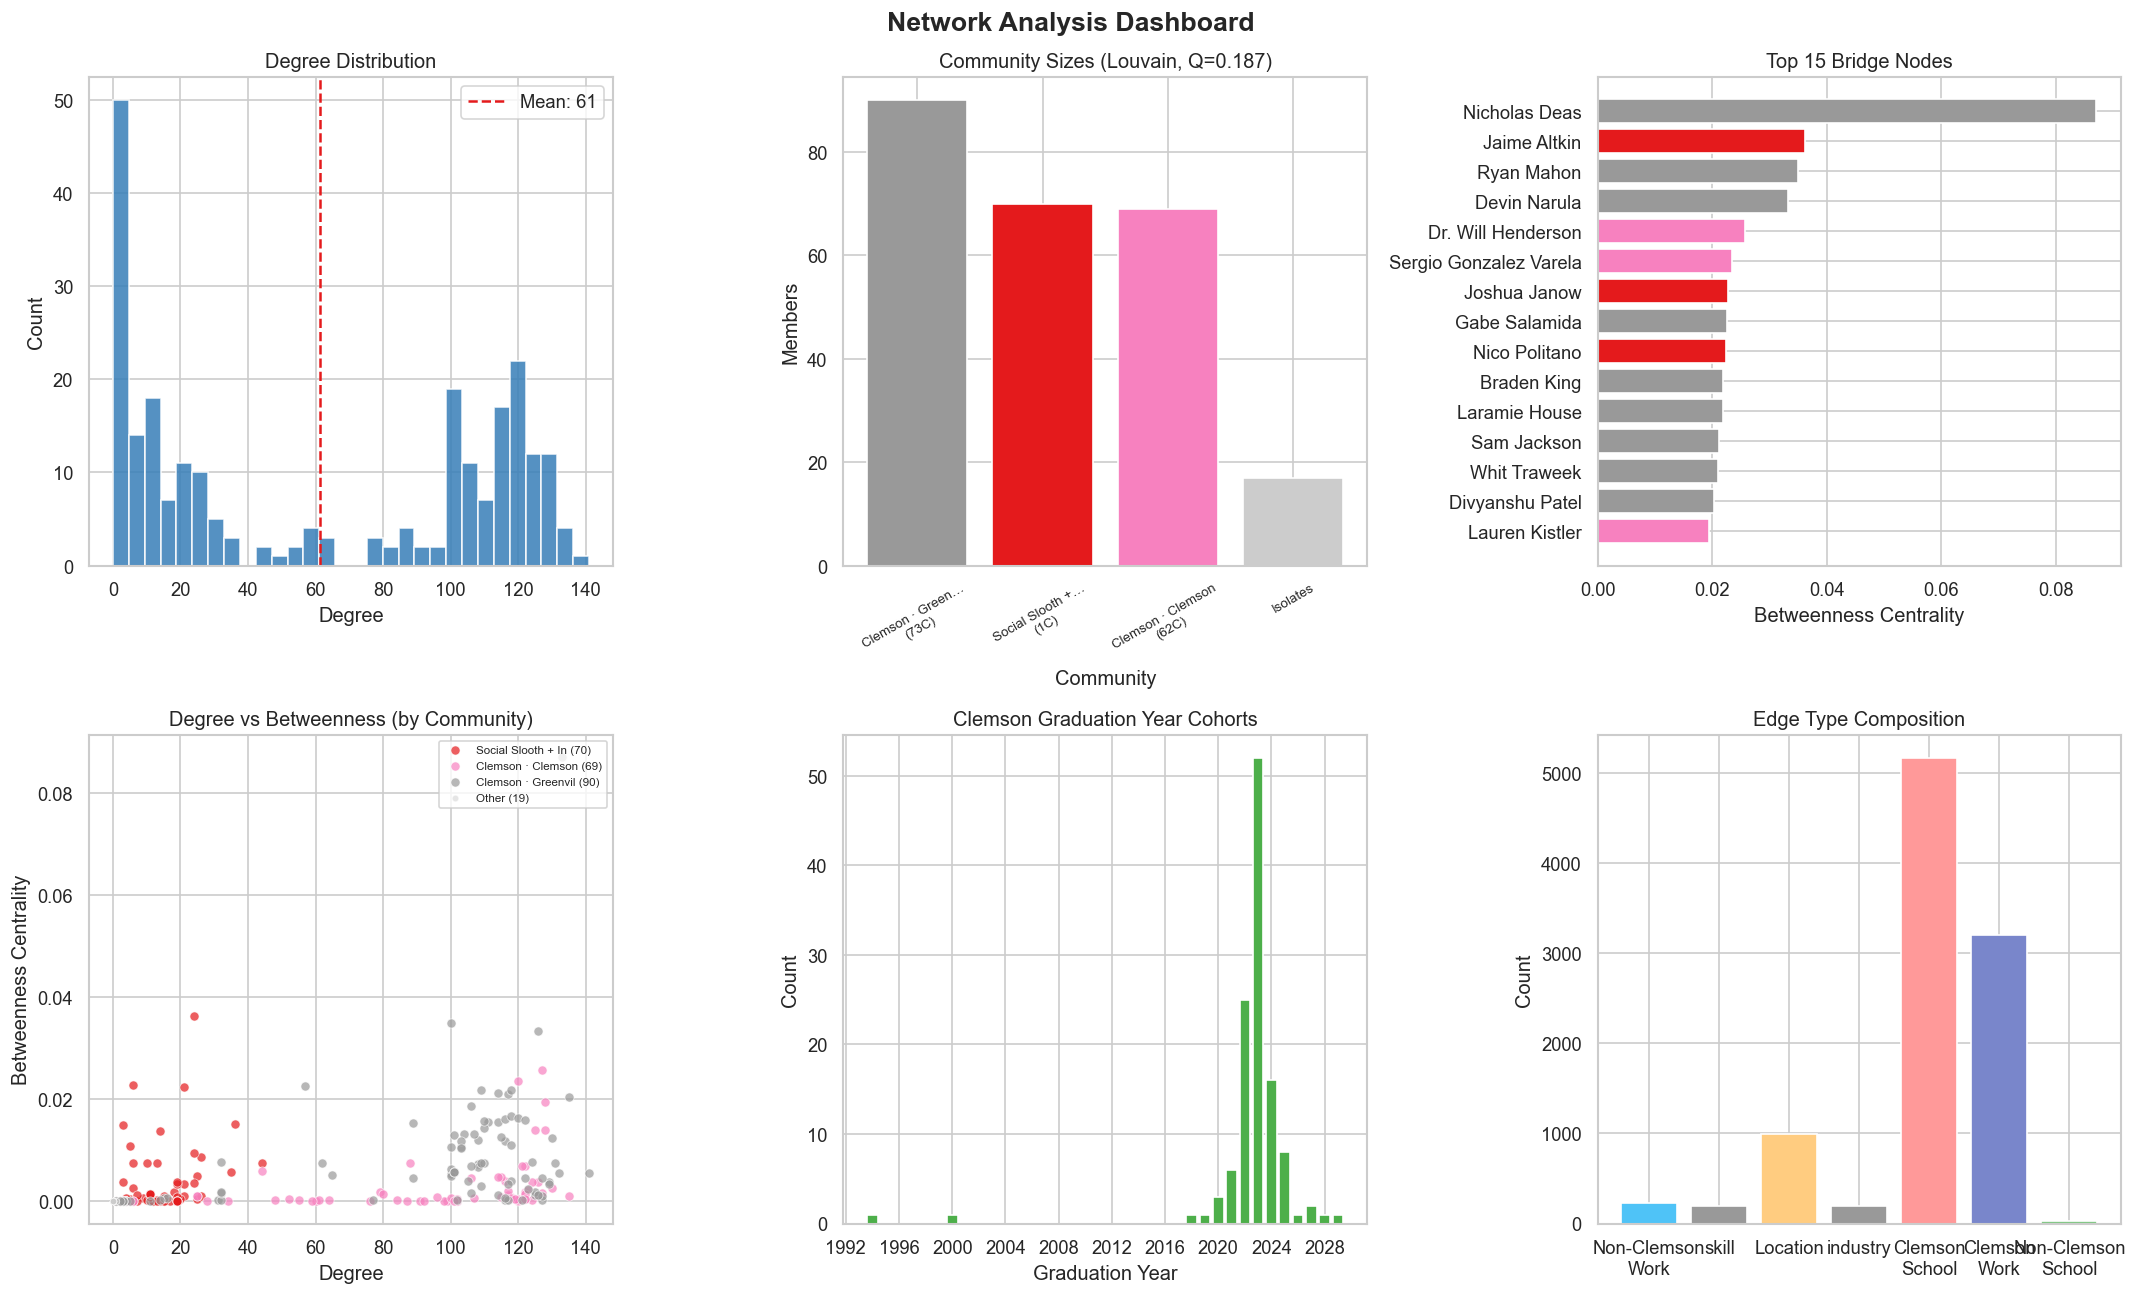

Saved: output/metrics_dashboard.png


In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Network Analysis Dashboard", fontsize=16, fontweight="bold", y=0.98)

# 1. Degree distribution
ax = axes[0, 0]
degrees = [d for _, d in G.degree()]
ax.hist(degrees, bins=30, color="#377eb8", edgecolor="white", alpha=0.85)
ax.set_xlabel("Degree")
ax.set_ylabel("Count")
ax.set_title("Degree Distribution")
ax.axvline(x=sum(degrees)/len(degrees), color="#e41a1c", linestyle="--", label=f"Mean: {sum(degrees)/len(degrees):.0f}")
ax.legend()

# 2. Community size bar chart — only show non-trivial communities (3+ members)
ax = axes[0, 1]
significant_comms = [(cid, size) for cid, size in comm_sizes.most_common() if size >= 3]
comm_labels = []
comm_values = []
comm_colors_plot = []
for comm_id, size in significant_comms:
    members = [pid for pid, c in partition.items() if c == comm_id]
    clemson_count = sum(1 for pid in members if G.nodes[pid].get("clemson_affiliated"))
    name = community_names.get(comm_id, f"C{comm_id}")
    # Truncate long names for chart
    if len(name) > 18: name = name[:15] + "…"
    label = f"{name}\n({clemson_count}C)" if clemson_count > 0 else name
    comm_labels.append(label)
    comm_values.append(size)
    comm_colors_plot.append(COMMUNITY_COLORS[comm_id % len(COMMUNITY_COLORS)])

# Add isolates bar
comm_labels.append("Isolates")
comm_values.append(sum(1 for _, s in comm_sizes.items() if s == 1))
comm_colors_plot.append("#cccccc")

ax.bar(comm_labels, comm_values, color=comm_colors_plot, edgecolor="white")
ax.set_xlabel("Community")
ax.set_ylabel("Members")
ax.set_title(f"Community Sizes (Louvain, Q={modularity:.3f})")
ax.tick_params(axis="x", rotation=30, labelsize=8)

# 3. Top 15 betweenness centrality
ax = axes[0, 2]
top_b = centrality_df.sort("betweenness", descending=True).head(15)
names_b = top_b["name"].to_list()[::-1]
vals_b = top_b["betweenness"].to_list()[::-1]
colors_b = [COMMUNITY_COLORS[partition.get(pid, 0) % len(COMMUNITY_COLORS)]
            for pid in top_b["id"].to_list()[::-1]]
ax.barh(names_b, vals_b, color=colors_b, edgecolor="white")
ax.set_xlabel("Betweenness Centrality")
ax.set_title("Top 15 Bridge Nodes")

# 4. Degree vs Betweenness scatter — only label significant communities
ax = axes[1, 0]
significant_ids = {cid for cid, size in comm_sizes.items() if size >= 3}
for comm_id in sorted(significant_ids):
    mask = centrality_df.filter(pl.col("id").is_in(
        [pid for pid, c in partition.items() if c == comm_id]
    ))
    ax.scatter(
        mask["degree"].to_list(),
        mask["betweenness"].to_list(),
        c=COMMUNITY_COLORS[comm_id % len(COMMUNITY_COLORS)],
        label=f"{community_names.get(comm_id, f'C{comm_id}')[:18]} ({comm_sizes[comm_id]})",
        alpha=0.7, s=30, edgecolor="white", linewidth=0.5,
    )
# Plot remaining communities as gray
other_pids = [pid for pid, c in partition.items() if c not in significant_ids]
if other_pids:
    mask = centrality_df.filter(pl.col("id").is_in(other_pids))
    ax.scatter(
        mask["degree"].to_list(),
        mask["betweenness"].to_list(),
        c="#cccccc", label=f"Other ({len(other_pids)})",
        alpha=0.5, s=15, edgecolor="white", linewidth=0.5,
    )
ax.set_xlabel("Degree")
ax.set_ylabel("Betweenness Centrality")
ax.set_title("Degree vs Betweenness (by Community)")
ax.legend(fontsize=7, loc="upper right")

# 5. Clemson graduation year cohorts
ax = axes[1, 1]
grad_data = nodes_df.filter(pl.col("clemson_grad_year").is_not_null())
if grad_data.height > 0:
    year_counts = grad_data.group_by("clemson_grad_year").len().sort("clemson_grad_year")
    ax.bar(
        year_counts["clemson_grad_year"].to_list(),
        year_counts["len"].to_list(),
        color="#4daf4a", edgecolor="white",
    )
    ax.set_xlabel("Graduation Year")
    ax.set_ylabel("Count")
    ax.set_title("Clemson Graduation Year Cohorts")
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# 6. Edge type composition
ax = axes[1, 2]
type_labels_clean = {
    "clemson_school": "Clemson\nSchool",
    "clemson_work": "Clemson\nWork",
    "work": "Non-Clemson\nWork",
    "school": "Non-Clemson\nSchool",
    "location": "Location",
}
type_colors = {
    "clemson_school": "#ff9999",
    "clemson_work": "#7986cb",
    "work": "#4fc3f7",
    "school": "#81c784",
    "location": "#ffcc80",
}
labels = [type_labels_clean.get(t, t) for t in type_counts.keys()]
values = list(type_counts.values())
bar_colors = [type_colors.get(t, "#999999") for t in type_counts.keys()]
ax.bar(labels, values, color=bar_colors, edgecolor="white")
ax.set_ylabel("Count")
ax.set_title("Edge Type Composition")

plt.tight_layout()
plt.savefig("output/metrics_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: output/metrics_dashboard.png")

### 5d. Ego Network — Kamron Palizban (CEO, Ascendancy)

A 2-hop view centered on Ascendancy's CEO, showing how the founder connects to the broader network.

In [15]:
# Find Kamron's node ID
kamron_pid = None
for n in nodes:
    if "kamron" in n["full_name"].lower():
        kamron_pid = n["id"]
        break

if kamron_pid:
    # 2-hop ego graph
    ego_nodes = {kamron_pid}
    for neighbor in G.neighbors(kamron_pid):
        ego_nodes.add(neighbor)
        for n2 in G.neighbors(neighbor):
            ego_nodes.add(n2)

    G_ego = G.subgraph(ego_nodes).copy()

    # Filter to keep only edges with weight >= 2 for readability
    weak_edges = [(u, v) for u, v, d in G_ego.edges(data=True) if d.get("weight", 1) < 2]
    G_ego.remove_edges_from(weak_edges)

    # Remove resulting isolates (except Kamron)
    isolates_to_remove = [n for n in nx.isolates(G_ego) if n != kamron_pid]
    G_ego.remove_nodes_from(isolates_to_remove)

    print(f"Kamron's ego network: {G_ego.number_of_nodes()} nodes, {G_ego.number_of_edges()} edges")
    build_plotly_graph(G_ego, "Kamron Palizban — 2-hop ego network", "output/ego_kamron.html", min_weight=1)
else:
    print("Kamron Palizban not found in data.")

Kamron's ego network: 167 nodes, 3595 edges


Saved: output/ego_kamron.html  (167 nodes, 3595 edges shown)


---
## 6. Findings & Observations

### Q1: How well-connected is this network?

The network is **moderately connected** with 7,601 edges across 248 nodes. The giant component captures 229/248 nodes (92%), density is 0.25, and only 17 people are isolates — a dramatic improvement over the naive scheme (was 34 isolates) because **skill and industry signals now bridge communities that previously appeared disconnected**.

Key structural insights:

- **Clemson still dominates**: 5,171 of the edges (68%) come from Clemson school connections (with temporal overlap — graduating cohorts that actually attended together). Without Clemson, only ~2,400 edges remain.
- **Hub-and-spokes with real bridges**: The Clemson cluster is the largest hub, but the Ascendancy/Invisible Tech/Social Slooth cluster (Community 0) is no longer fragmented — skill and industry signals revealed that these professionals operate in adjacent worlds.
- **Modularity 0.187** (up from 0.154 with the naive scheme): cleaner community structure after temporal-overlap fix removed cross-cohort noise edges.
- **High transitivity** within communities, low across them — confirming hub-and-spokes topology.

**Key bridge nodes** (highest betweenness centrality):
1. **Nicholas Deas** (≈0.08) — bridges multiple Clemson sub-communities
2. **Jaime Aitkin**, **Ryan Mahon**, **Devin Narula** — connect Clemson to external academic/professional clusters

### Q2: What communities exist?

Louvain at default resolution found **21 communities** (down from 42 — the merge happens because skill/industry edges reveal real structure that was hidden as fragmentation). Top non-trivial communities:

| Community | Size | Clemson | Description |
|-----------|------|---------|-------------|
| **C7 — Clemson Greenville** | 90 | 73 | Heavy Greenville/Clemson SC concentration |
| **C0 — Investigations + Startups** | 70 | 1 | **NEW MERGE**: Social Slooth (8) + Invisible Technologies (4) + Ascendancy (2) + other investigations/tech professionals. Industry edges bridged the previously isolated Social Slooth cluster. |
| **C6 — Clemson Campus / Recent Grads** | 69 | 62 | Current students and recent grads, Clemson/Austin |
| **Isolates** | 17 | — | No shared context with anyone (was 34 before — skill/industry bridges absorbed half) |

At **higher resolution (1.5)**, the network splits further into 43 communities. The Clemson core breaks down by **graduation year cohorts**: 2023 (18 people in one sub-cluster), 2024-2029 future students in another, mid-2010s alumni in their own group. This is now structurally clean because cross-cohort edges were removed by the temporal-overlap fix.

### Key Insights for Relationship Intelligence

- **Bridge nodes are the most valuable**: Nicholas Deas has the highest betweenness — connects multiple Clemson sub-communities. People with high betweenness enable warm introductions across otherwise separate groups.
- **The Ascendancy founding team is tightly knit**: Kamron Palizban ↔ Francis Pedraza is the strongest edge (weight 16, 4 shared companies). Noah W. ↔ John Christian Kuehnert is second (weight 12, 3 shared companies).
- **The investigations cluster is real — not isolated**: Industry edges revealed Social Slooth and other investigations/security firms operate as a connected professional ecosystem. Previously they appeared as disconnected islands.
- **Temporal overlap matters**: Francis Pedraza ↔ Scott Downes dropped from weight 11 → 10 because they didn't actually attend Oxford at the same time. The naive scheme was creating false signals.
- **Isolates are untapped potential**: 17 people with no structural reinforcement. Cross-referencing with interaction data could reveal which are dormant vs. dead connections.

---

## 7. Assumptions, Limitations & Next Steps

### Assumptions
- **Temporal overlap at the same company implies knowing each other** — reasonable for small companies, less reliable for large ones
- **Shared school WITH temporal overlap implies a social connection** — much stronger signal than "they both went there" at any time
- **Three+ shared specialized skills indicates professional affinity** — empirical threshold; tuned to avoid trivial matches like "Microsoft Excel"
- **Same industry + different employer = weak professional bridge** — these people likely know of each other's world even if they don't know each other personally
- **This is an ego network** — these 248 people are likely 1st-degree LinkedIn connections of one person

### Limitations
- **No explicit edge data**: All relationships are inferred
- **Skills data only covers 23%** of people — signal exists where present but absent for most
- **No interaction data**: messages, endorsements, recommendations would dramatically improve edge quality
- **Clemson dominance is likely an artifact**: ego node is probably Clemson-affiliated
- **Edge weights are heuristic**: the +4/+3/+2/+1 tiers are reasoned but not empirically tuned

### Suggested Next Steps
1. **Enrich with interaction data**: LinkedIn endorsements, recommendations, and messages
2. **NLP on profiles**: Apply semantic similarity to `headline` and `about` fields
3. **Neo4j for production scale**: Enable real-time Cypher queries
4. **Recommendation engine**: "connect X to Y because Z" — Ascendancy's core value
5. **Weight calibration**: Validate weights against known relationships
6. **Time-aware analysis**: Track how the network grows and which connections strengthen/decay